In [1]:
import os, urllib.request, json, math, copy, time, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.transforms.functional import InterpolationMode
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler

from linear_attention import replace_vit_self_attention_with_linear

In [2]:
# -------------------
# Knobs
# -------------------
LINEAR_APPROX = "relu"    # Choose: relu, elu1, favor, hswish

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
BATCH_SIZE_TRAIN = 128        # adjust to your GPU
BATCH_SIZE_VAL   = 256
NUM_WORKERS = 16               # adjust to your CPU/IO

# Training regime
EPOCHS = 30
WARMUP_PCT = 0.05
LABEL_SMOOTH = 0.1
WD = 0.05
LR_HEAD = 3e-4               # classifier head LR
LR_BODY = 3e-5               # encoder LR (when unfrozen)

# Finetune modes
FULL_FINETUNE   = True       # unfreeze entire model
UNFREEZE_LAST_K = 3          # used only when FULL_FINETUNE == False

CLIP_NORM = 1.0
USE_AMP = (DEVICE == "cuda")

SAVE_DIR = f"./vit_linear_{LINEAR_APPROX}_finetuned_imagenet"

In [3]:
from transformers import (
    AutoImageProcessor, ViTForImageClassification,
    get_cosine_schedule_with_warmup
)

torch.manual_seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

/home/uttej/work/linear_attn/sw/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# -------------------
# 0) Use local ImageNet layout
# -------------------
DATA_ROOT = "./dataset/imagenet"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
assert os.path.isdir(TRAIN_DIR) and os.path.isdir(VAL_DIR), \
    f"Expected ImageNet folders at {TRAIN_DIR} and {VAL_DIR}"

In [5]:
# -------------------
# 1) Load base model + processor
# -------------------
MODEL_NAME = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast=True)
baseline  = ViTForImageClassification.from_pretrained(
    MODEL_NAME, output_attentions=False
).to(DEVICE).eval()

In [6]:
# -------------------
# 2) Linear Self-Attention block
# -------------------
linear = copy.deepcopy(baseline)
replace_vit_self_attention_with_linear(linear, impl=LINEAR_APPROX)
linear.to(DEVICE)


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ReLULinearSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in

In [7]:
# -------------------
# 3) Datasets & Loaders
# -------------------
short_edge = processor.size.get("shortest_edge", 256)
target = processor.size.get("height", 224)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(target, scale=(0.08, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])
val_tf = transforms.Compose([
    transforms.Resize(short_edge, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(target),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

ds_train = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
ds_val   = datasets.ImageFolder(VAL_DIR,   transform=val_tf)

dl_train = DataLoader(
    ds_train, batch_size=BATCH_SIZE_TRAIN, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=(NUM_WORKERS > 0)
)
dl_val   = DataLoader(
    ds_val, batch_size=BATCH_SIZE_VAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

In [8]:
# -------------------
# 4) Head handling:
#    - if 1000 classes: KEEP pretrained head and REMAP labels to HF id order
#    - else: re-init classifier to num_classes (like Imagenette case)
# -------------------
num_feats    = linear.config.hidden_size
num_classes  = len(ds_train.classes)
hf_num_labels= int(baseline.config.num_labels)

LABEL_LUT = None  # maps local label idx -> HF id idx (if 1k)

if num_classes == hf_num_labels:
    # Build mapping from local class list (sorted WNIDs) -> HF id order
    IMAGENET_CLASS_INDEX_URL = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
    with urllib.request.urlopen(IMAGENET_CLASS_INDEX_URL) as f:
        cls_index = json.load(f)  # "0":[wnid,human], ...
    hf_idx2wnid = {int(k): v[0] for k, v in cls_index.items()}
    wnid2hfidx  = {wnid: idx for idx, wnid in hf_idx2wnid.items()}

    local_classes = ds_train.classes  # list of WNIDs (e.g., 'n01440764', ...)
    # Safety: ensure all are WNIDs
    assert all(c.startswith("n") and len(c) == 9 for c in local_classes), \
        "Expected ImageNet class folders to be WNIDs like 'n01440764'."

    lut_list = [wnid2hfidx[wnid] for wnid in local_classes]
    LABEL_LUT = torch.tensor(lut_list, device=DEVICE, dtype=torch.long)

    # Keep existing head weights (pretrained 1k)
    linear.config.num_labels = num_classes
    # (optional) keep id2label consistent with local order for readability
    linear.config.id2label = {i: wnid for i, wnid in enumerate(local_classes)}
    linear.config.label2id = {wnid: i for i, wnid in enumerate(local_classes)}
else:
    # Re-init head for custom class count
    linear.classifier = nn.Linear(num_feats, num_classes)
    torch.nn.init.trunc_normal_(linear.classifier.weight, std=0.02)
    nn.init.zeros_(linear.classifier.bias)
    linear.config.num_labels = num_classes
    linear.config.id2label = {i: c for i, c in enumerate(ds_train.classes)}
    linear.config.label2id = {c: i for i, c in enumerate(ds_train.classes)}
    linear.to(DEVICE)

In [9]:
# -------------------
# 5) Freeze/unfreeze helper
# -------------------
def configure_trainable(model, full_finetune=False, last_k=3):
    for p in model.parameters():
        p.requires_grad = False

    if full_finetune:
        for p in model.vit.parameters():
            p.requires_grad = True
    else:
        enc = model.vit.encoder.layer
        k = min(last_k, len(enc))
        for blk in enc[-k:]:
            for p in blk.parameters():
                p.requires_grad = True

    # Always unfreeze final LayerNorm and classifier head
    for p in model.vit.layernorm.parameters():
        p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True

configure_trainable(linear, full_finetune=FULL_FINETUNE, last_k=UNFREEZE_LAST_K)

In [10]:
# -------------------
# 6) Optimizer, loss, schedule
# -------------------
def param_groups(model):
    groups = []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        lr = LR_HEAD if n.startswith("classifier") else LR_BODY
        wd = 0.0 if p.ndim == 1 else WD
        groups.append({"params": [p], "lr": lr, "weight_decay": wd})
    return groups

optimizer = torch.optim.AdamW(param_groups(linear), betas=(0.9, 0.999), eps=1e-8)
total_steps = EPOCHS * len(dl_train)
warmup_steps = max(1, int(WARMUP_PCT * total_steps))
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
# scaler = GradScaler(enabled=USE_AMP)

In [11]:
# -------------------
# 7) Eval helpers
# -------------------
@torch.no_grad()
def eval_top1(model, loader, label_lut=None):
    """Top-1 over full dataset; if label_lut is provided, map local -> HF id space."""
    model.eval()
    correct, seen = 0, 0
    for imgs, labels in loader:
        imgs  = imgs.to(DEVICE, non_blocking=True)
        labels= labels.to(DEVICE, non_blocking=True)
        if label_lut is not None:
            labels = label_lut[labels]  # remap to HF id order
        with torch.amp.autocast('cuda', enabled=USE_AMP):
        # with autocast(enabled=USE_AMP):
            logits = model(pixel_values=imgs).logits
        pred = logits.argmax(-1)
        correct += (pred == labels).sum().item()
        seen    += labels.numel()
    return correct / max(seen, 1)

# Sanity check before training
print("Sanity (val, linear model before FT):", f"{eval_top1(linear, dl_val, LABEL_LUT)*100:.2f}%")
BASELINE_VAL = eval_top1(baseline, dl_val, LABEL_LUT)
print("Baseline (val, pretrained softmax)  :", f"{BASELINE_VAL*100:.2f}%")

Sanity (val, linear model before FT): 1.59%
Baseline (val, pretrained softmax)  : 81.67%


In [12]:
# -------------------
# 8) Train loop (save best) + per-epoch logs
# -------------------
os.makedirs(SAVE_DIR, exist_ok=True)
best_acc = -1.0
best_path = os.path.join(SAVE_DIR, f"best_linear_{LINEAR_APPROX}.pt")

hist = {"epoch": [], "train_loss": [], "val_acc_linear": [], "val_acc_baseline": []}

for epoch in range(1, EPOCHS+1):
    linear.train()
    running = 0.0
    t0 = time.time()
    for imgs, labels in dl_train:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        if LABEL_LUT is not None:
            # Map to HF id space so loss targets match model's logits ordering
            labels = LABEL_LUT[labels]

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
        # with autocast(enabled=USE_AMP):
            logits = linear(pixel_values=imgs).logits
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(linear.parameters(), CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running += loss.item()

    val_acc = eval_top1(linear, dl_val, LABEL_LUT)
    epoch_time = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | loss {running/len(dl_train):.4f} | val@1 {val_acc*100:.2f}% | {epoch_time/60:.1f}m")

    # Save best
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({"state_dict": linear.state_dict(),
                    "config": linear.config.to_dict(),
                    "classes": ds_train.classes},
                   best_path)
        print(f"  ↳ New best! Saved to {best_path}")

    # Log history
    hist["epoch"].append(epoch)
    hist["train_loss"].append(running/len(dl_train))
    hist["val_acc_linear"].append(val_acc)
    hist["val_acc_baseline"].append(BASELINE_VAL)  # constant reference

print(f"\nBest val@1 (linear): {best_acc*100:.2f}%")

Epoch 01/30 | loss 3.1837 | val@1 66.63% | 54.0m
  ↳ New best! Saved to ./vit_linear_relu_finetuned_imagenet/best_linear_relu.pt
Epoch 02/30 | loss 2.1552 | val@1 72.58% | 53.9m
  ↳ New best! Saved to ./vit_linear_relu_finetuned_imagenet/best_linear_relu.pt
Epoch 03/30 | loss 1.9739 | val@1 74.84% | 53.6m
  ↳ New best! Saved to ./vit_linear_relu_finetuned_imagenet/best_linear_relu.pt
Epoch 04/30 | loss 1.8916 | val@1 75.66% | 53.5m
  ↳ New best! Saved to ./vit_linear_relu_finetuned_imagenet/best_linear_relu.pt
Epoch 05/30 | loss 1.8392 | val@1 75.89% | 53.5m
  ↳ New best! Saved to ./vit_linear_relu_finetuned_imagenet/best_linear_relu.pt
Epoch 06/30 | loss 1.7964 | val@1 76.50% | 53.4m
  ↳ New best! Saved to ./vit_linear_relu_finetuned_imagenet/best_linear_relu.pt
Epoch 07/30 | loss 1.7607 | val@1 76.72% | 53.4m
  ↳ New best! Saved to ./vit_linear_relu_finetuned_imagenet/best_linear_relu.pt
Epoch 08/30 | loss 1.7325 | val@1 77.09% | 53.3m
  ↳ New best! Saved to ./vit_linear_relu_finetun

In [13]:
# -------------------
# 9) Load best and export to TorchScript
# -------------------
ckpt = torch.load(best_path, map_location=DEVICE)
linear.load_state_dict(ckpt["state_dict"])
linear.to(DEVICE)

class ViTCLSWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, pixel_values: torch.Tensor):
        return self.m(pixel_values=pixel_values).logits

ts = ViTCLSWrapper(linear).eval().to(DEVICE)
example = torch.randn(1, 3, 224, 224, device=DEVICE)
scripted = torch.jit.trace(ts, (example,))
scripted.save(os.path.join(SAVE_DIR, "model_ts.pt"))
print("Saved TorchScript to:", os.path.join(SAVE_DIR, "model_ts.pt"))

/home/uttej/work/linear_attn/sw/.venv/lib/python3.12/site-packages/transformers/modeling_utils.py:4713: FutureWarning: `_is_quantized_training_enabled` is going to be deprecated in transformers 4.39.0. Please use `model.hf_quantizer.is_trainable` instead
  warnings.warn(
/home/uttej/work/linear_attn/sw/.venv/lib/python3.12/site-packages/transformers/models/vit/modeling_vit.py:163: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if num_channels != self.num_channels:
/home/uttej/work/linear_attn/sw/.venv/lib/python3.12/site-packages/transformers/models/vit/modeling_vit.py:169: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future

Saved TorchScript to: ./vit_linear_relu_finetuned_imagenet/model_ts.pt


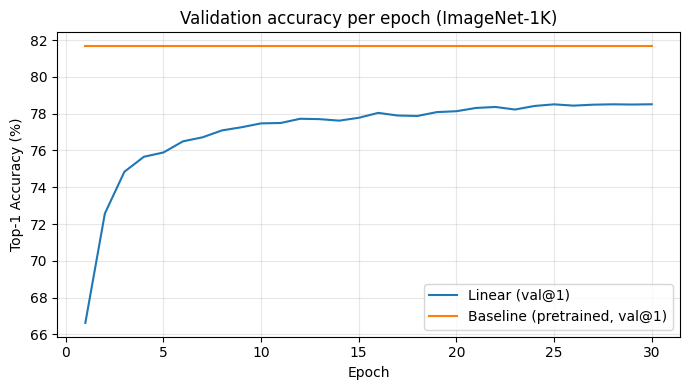

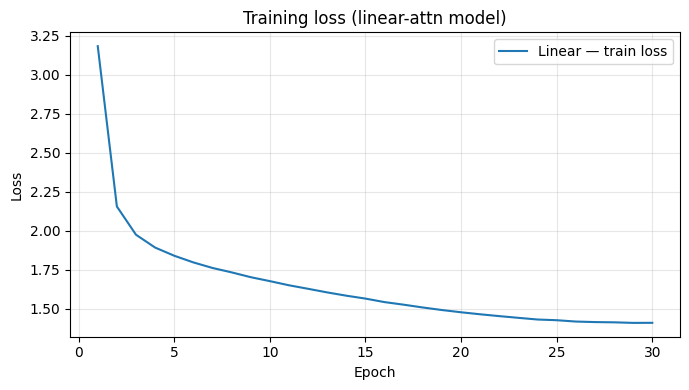

In [14]:
# -------------------
# 10) Plots
# -------------------
epochs = hist["epoch"]
plt.figure(figsize=(7,4))
plt.plot(epochs, [a*100 for a in hist["val_acc_linear"]], label="Linear (val@1)")
plt.plot(epochs, [a*100 for a in hist["val_acc_baseline"]], label="Baseline (pretrained, val@1)")
plt.xlabel("Epoch"); plt.ylabel("Top-1 Accuracy (%)")
plt.title("Validation accuracy per epoch (ImageNet-1K)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.plot(epochs, hist["train_loss"], label="Linear — train loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training loss (linear-attn model)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()